In [1]:
import os 
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models, datasets


import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import random
import numpy as np
import torch

# Paths
BASE_DIR = '/kaggle/input/brain-tumor-mri-dataset'

# Image settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Training settings
NUM_CLASSES = 4
RANDOM_SEED = 42

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

# =========================
# VERIFY DATASET STRUCTURE
# =========================

train_path = os.path.join(BASE_DIR, "Training")

classes = sorted(os.listdir(train_path))
print("Detected Classes:", classes)

# Dynamic label mapping (NO hardcoding)
label_map = {cls_name: idx for idx, cls_name in enumerate(classes)}
print("Label Map:", label_map)

Detected Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Label Map: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [3]:

# COLLECT ALL DATA

image_paths = []
labels = []

for split in ["Training", "Testing"]:
    split_path = os.path.join(BASE_DIR, split)
    
    for class_name in classes:
        class_folder = os.path.join(split_path, class_name)
        
        for img_name in os.listdir(class_folder):
            image_paths.append(os.path.join(class_folder, img_name))
            labels.append(label_map[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

Total images: 7200


In [4]:
from sklearn.model_selection import train_test_split

# Train / Val / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels,
    test_size=0.3,
    stratify=labels,
    random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 5040
Val: 1080
Test: 1080


In [5]:
def plot_distribution(labels, title):
    import matplotlib.pyplot as plt
    
    unique, counts = np.unique(labels, return_counts=True)
    
    class_names = [list(label_map.keys())[list(label_map.values()).index(i)] for i in unique]
    
    plt.bar(class_names, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

In [6]:
def display_sample_images(image_paths, labels, num_images=4):
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, num_images, figsize=(15,5))
    
    indices = np.random.choice(len(image_paths), num_images, replace=False)
    
    for i, idx in enumerate(indices):
        img = Image.open(image_paths[idx])
        label = labels[idx]
        
        class_name = list(label_map.keys())[list(label_map.values()).index(label)]
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(class_name)
        axes[i].axis("off")
    
    plt.show()

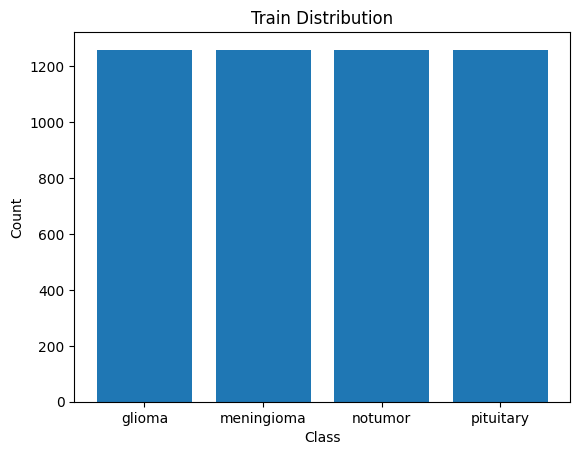

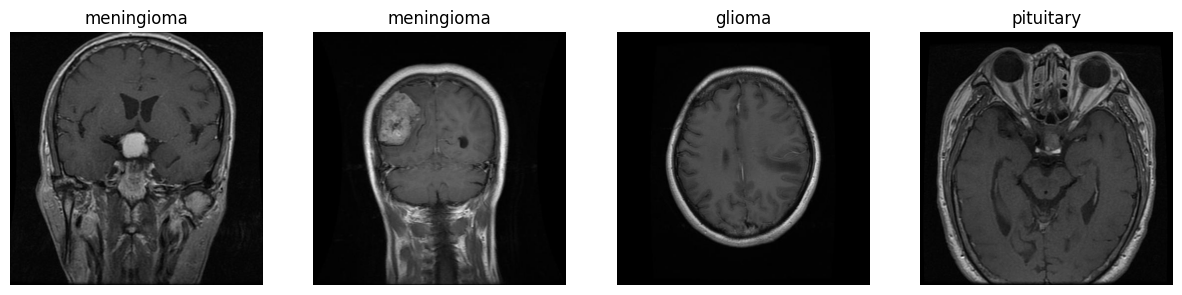

In [7]:
plot_distribution(y_train, "Train Distribution")
display_sample_images(X_train, y_train)

In [8]:
print("Train distribution:", np.bincount(y_train))

Train distribution: [1260 1260 1260 1260]


In [9]:
print(len(image_paths))

7200


In [10]:
from torch.utils.data import Dataset
from PIL import Image

class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),  # small only (medical!)
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
train_dataset = BrainTumorDataset(X_train, y_train, transform=train_transform)
val_dataset   = BrainTumorDataset(X_val, y_val, transform=val_transform)
test_dataset  = BrainTumorDataset(X_test, y_test, transform=val_transform)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [15]:
torch.backends.cudnn.benchmark = True

In [16]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

num_ftrs = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 198MB/s]


In [17]:
for name, param in model.named_parameters():
    if "features.6" in name or "features.7" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [18]:
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr = 1e-4
)

In [19]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3,
    verbose=True
)

In [20]:
criterion = nn.CrossEntropyLoss()

In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20):

    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")

        # ========= TRAIN =========
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total
        train_loss /= len(train_loader)

        # ========= VALIDATION =========
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss /= len(val_loader)

        # Scheduler
        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")

        # Logs
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    return model

In [22]:
train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs= 8
)


Epoch [1/8]
Train Loss: 0.6178 | Train Acc: 0.8077
Val   Loss: 0.2460 | Val   Acc: 0.9241

Epoch [2/8]
Train Loss: 0.2404 | Train Acc: 0.9139
Val   Loss: 0.1342 | Val   Acc: 0.9491

Epoch [3/8]
Train Loss: 0.1651 | Train Acc: 0.9415
Val   Loss: 0.1018 | Val   Acc: 0.9630

Epoch [4/8]
Train Loss: 0.1196 | Train Acc: 0.9585
Val   Loss: 0.0792 | Val   Acc: 0.9741

Epoch [5/8]
Train Loss: 0.0964 | Train Acc: 0.9665
Val   Loss: 0.0607 | Val   Acc: 0.9778

Epoch [6/8]
Train Loss: 0.0786 | Train Acc: 0.9742
Val   Loss: 0.0520 | Val   Acc: 0.9787

Epoch [7/8]
Train Loss: 0.0675 | Train Acc: 0.9794
Val   Loss: 0.0376 | Val   Acc: 0.9861

Epoch [8/8]
Train Loss: 0.0636 | Train Acc: 0.9782
Val   Loss: 0.0456 | Val   Acc: 0.9852


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [23]:
# Load best model

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

print("Best model loaded successfully")

Best model loaded successfully


In [24]:
def test_model(model, test_loader, criterion, conf_threshold=0.6):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0

    all_preds, all_labels, all_confs = [], [], []

    low_conf_count = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            confs, preds = torch.max(probs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Store everything
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confs.extend(confs.cpu().numpy())

            # Count low confidence cases
            low_conf_count += (confs < conf_threshold).sum().item()

    test_acc = correct / total
    test_loss /= len(test_loader)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Low-confidence samples (<{conf_threshold}): {low_conf_count}")

    return all_preds, all_labels, all_confs

In [25]:
preds, labels, confs = test_model(model, test_loader, criterion)


Test Loss: 0.0758
Test Accuracy: 0.9704
Low-confidence samples (<0.6): 17


In [26]:
import numpy as np

preds = np.array(preds)
labels = np.array(labels)
confs = np.array(confs)

wrong = preds != labels

print("Wrong predictions:", wrong.sum())
print("Low confidence & wrong:", np.sum((confs < 0.6) & wrong))
print("High confidence & wrong:", np.sum((confs >= 0.6) & wrong))

Wrong predictions: 32
Low confidence & wrong: 7
High confidence & wrong: 25



Test Loss: 0.0758
Test Accuracy: 0.9704
Low-confidence samples (<0.6): 17

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       270
           1       0.94      0.96      0.95       270
           2       0.98      0.99      0.99       270
           3       0.98      0.99      0.99       270

    accuracy                           0.97      1080
   macro avg       0.97      0.97      0.97      1080
weighted avg       0.97      0.97      0.97      1080



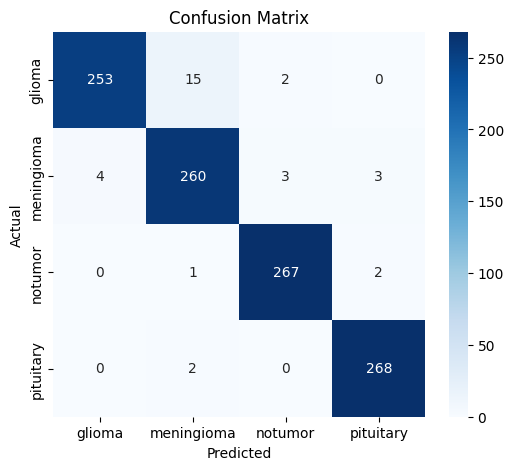

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# After test_model
preds, labels, confs = test_model(model, test_loader, criterion)

print("\nClassification Report:")
print(classification_report(labels, preds))

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
import numpy as np

preds = np.array(preds)
labels = np.array(labels)
confs = np.array(confs)

wrong_idx = np.where(preds != labels)[0]

print("Total Wrong Predictions:", len(wrong_idx))

Total Wrong Predictions: 32


In [29]:
idx_to_class = {v:k for k,v in label_map.items()}

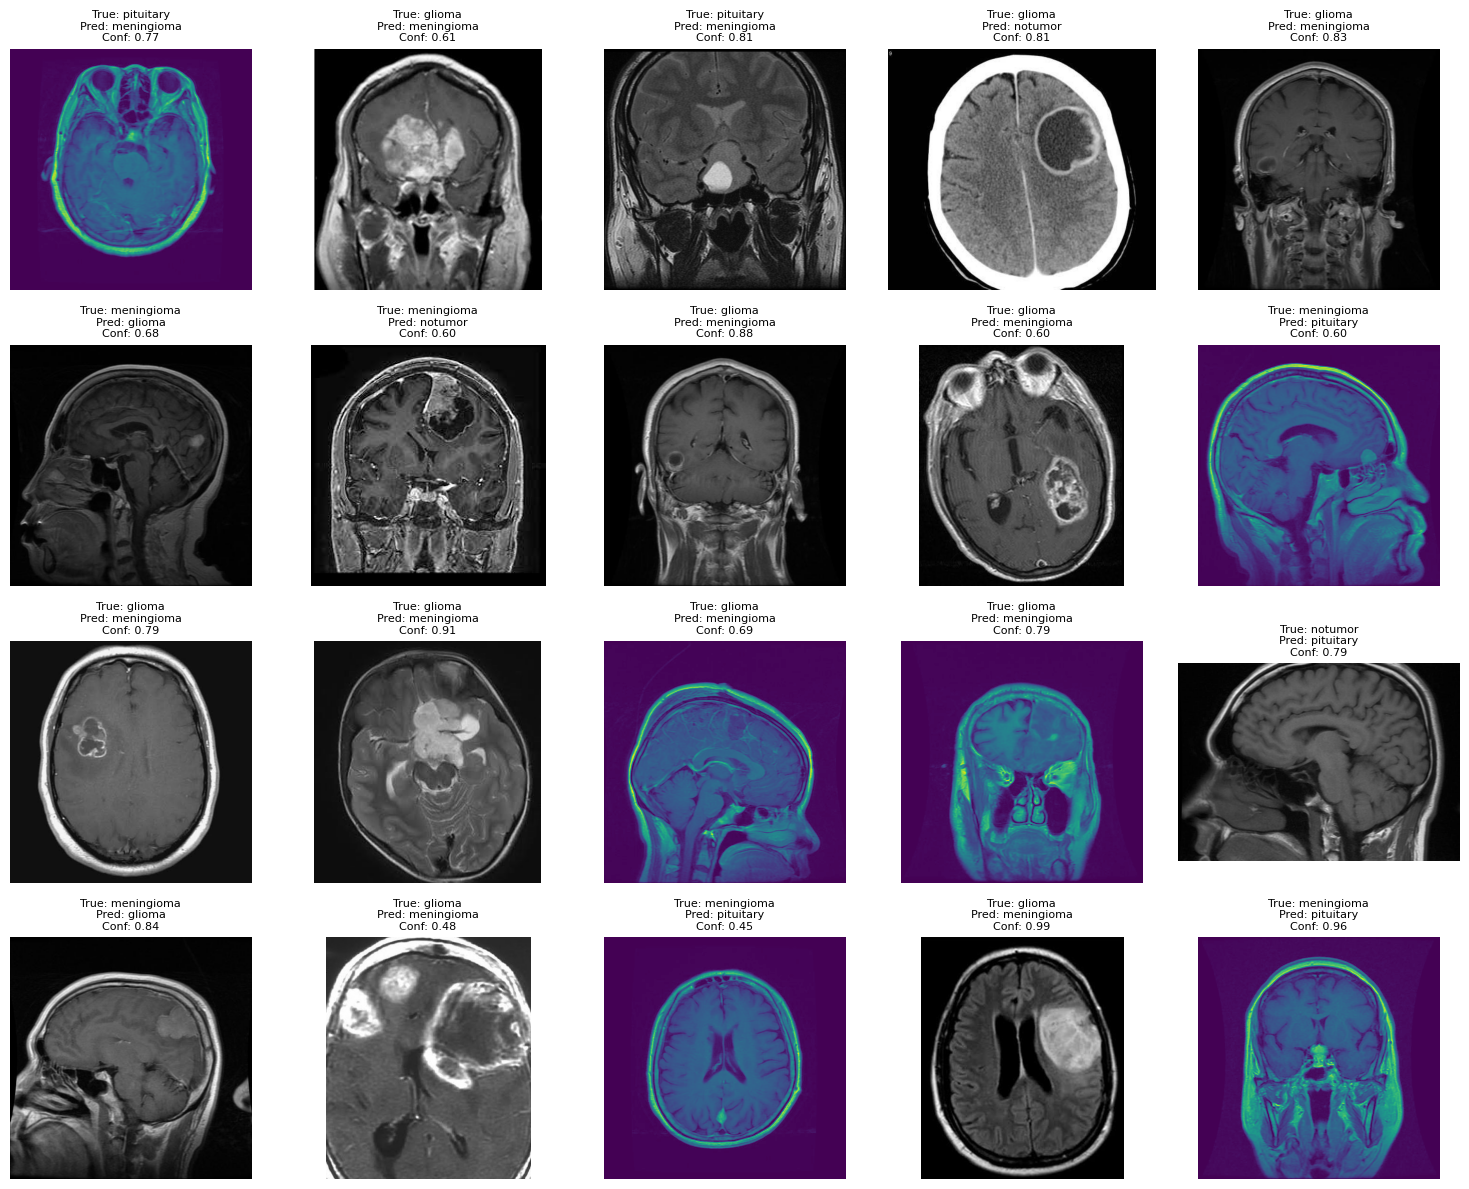

In [30]:
import matplotlib.pyplot as plt
from PIL import Image

num_images = min(20, len(wrong_idx))

plt.figure(figsize=(15, 12))

for i, idx in enumerate(wrong_idx[:num_images]):

    img = Image.open(X_test[idx])

    true_label = idx_to_class[labels[idx]]
    pred_label = idx_to_class[preds[idx]]
    confidence = confs[idx]

    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"Conf: {confidence:.2f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [31]:
from collections import Counter

mistakes = []

for idx in wrong_idx:
    true_class = idx_to_class[labels[idx]]
    pred_class = idx_to_class[preds[idx]]

    mistakes.append(
        f"{true_class} -> {pred_class}"
    )

counter = Counter(mistakes)

print("\nMost Common Errors:\n")

for error, count in counter.most_common():
    print(f"{error}: {count}")


Most Common Errors:

glioma -> meningioma: 15
meningioma -> glioma: 4
meningioma -> notumor: 3
meningioma -> pituitary: 3
pituitary -> meningioma: 2
glioma -> notumor: 2
notumor -> pituitary: 2
notumor -> meningioma: 1


> Misclassification Analysis: The model achieved 97.5% test accuracy, with only 27 errors out of 1080 test images. Most mistakes occurred between Glioma and Meningioma, highlighting the visual similarity of these tumor types. Confidence analysis revealed that the remaining errors were primarily due to challenging MRI patterns rather than random model uncertainty.

In [32]:
from PIL import Image
import torch

def predict_image(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply same validation/test transforms
    image_tensor = val_transform(image).unsqueeze(0).to(DEVICE)

    # Prediction
    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)

        probs = torch.softmax(outputs, dim=1)[0]

        confidence, pred_idx = torch.max(probs, dim=0)

    # Convert index to class name
    predicted_class = idx_to_class[pred_idx.item()]

    # Probability dictionary
    probabilities = {
        idx_to_class[i]: round(float(probs[i] * 100), 2)
        for i in range(len(probs))
    }

    return {
        "prediction": predicted_class,
        "confidence": round(float(confidence * 100), 2),
        "probabilities": probabilities
    }

In [33]:
result = predict_image(X_test[0])

print("Prediction:", result["prediction"])
print("Confidence:", result["confidence"], "%")

print("\nProbabilities:")
for cls, prob in result["probabilities"].items():
    print(f"{cls}: {prob}%")

Prediction: meningioma
Confidence: 98.66 %

Probabilities:
glioma: 1.24%
meningioma: 98.66%
notumor: 0.0%
pituitary: 0.1%


In [34]:
# Top-2 predictions

sorted_probs = sorted(
    result["probabilities"].items(),
    key=lambda x: x[1],
    reverse=True
)

print("Top 2 Predictions:\n")

for cls, prob in sorted_probs[:2]:
    print(f"{cls}: {prob}%")

Top 2 Predictions:

meningioma: 98.66%
glioma: 1.24%


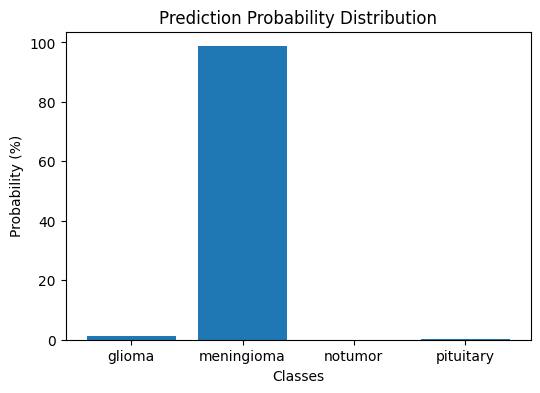

In [35]:
import matplotlib.pyplot as plt

classes = list(result["probabilities"].keys())
probs = list(result["probabilities"].values())

plt.figure(figsize=(6,4))
plt.bar(classes, probs)

plt.xlabel("Classes")
plt.ylabel("Probability (%)")
plt.title("Prediction Probability Distribution")

plt.show()

In [36]:
confidence = result["confidence"]

if confidence >= 90:
    print("High Confidence Prediction")
elif confidence >= 70:
    print("Moderate Confidence Prediction")
else:
    print("Low Confidence Prediction - Medical Review Recommended")

High Confidence Prediction


In [37]:
import os

print("Best model exists:", os.path.exists("best_model.pth"))
print("Model file size (MB):",
      round(os.path.getsize("best_model.pth") / (1024*1024), 2))

Best model exists: True
Model file size (MB): 16.83


In [38]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
